# **OLA Booking App** EXPLORATORY DATA ANALYSIS

In [1]:
!pip install xgboost scikit-learn

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Bookings_dataset/Bookings.csv')

df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,#NAME?,NaN
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,No,NaN,158,Cash,13,4.1,4.0,#NAME?,NaN
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,No,NaN,386,UPI,40,4.2,4.8,#NAME?,NaN
3,2024-07-22 3:15:00,3:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,NaN,NaN,384,NaN,0,NaN,NaN,#NAME?,NaN
4,2024-07-02 9:02:00,9:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,No,NaN,822,Credit Card,45,4.0,3.0,#NAME?,NaN


### Data Preprocessing and Feature Engineering



In [27]:
# Drop unnecessary columns, ignoring errors if columns are already absent
df.drop(['Vehicle Images', 'Unnamed: 20'], axis=1, inplace=True, errors='ignore')

# Convert 'Date' to datetime format if not already
df['Date'] = pd.to_datetime(df['Date'])

# Extract 'Hour' from 'Time' column (assuming 'Time' is in a parsable format)
# Explicitly specifying format to avoid UserWarning and ensure consistent parsing
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour

# Extract 'Day' and 'Month' from 'Date' column
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month

# Create the Target variable: 1 for 'Canceled' bookings, 0 otherwise
df['Target'] = df['Booking_Status'].apply(lambda x: 1 if 'Canceled' in str(x) else 0)

# Fill missing values using forward-fill method
# Using .ffill() directly to address FutureWarning
df.ffill(inplace=True)

df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Hour,Day,Month,Target
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,NaN,444,NaN,0,NaN,NaN,14,26,7,1
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,158,Cash,13,4.1,4.0,22,25,7,0
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,386,UPI,40,4.2,4.8,19,30,7,0
3,2024-07-22 03:15:00,3:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,238.0,130.0,...,NaN,384,UPI,0,4.2,4.8,3,22,7,1
4,2024-07-02 09:02:00,9:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,822,Credit Card,45,4.0,3.0,9,2,7,0


In [20]:
cat_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()

# Exclude 'Booking_Status' from label encoding as it's used for target creation and then dropped
cat_cols_to_encode = [col for col in cat_cols if col != 'Booking_Status']

for col in cat_cols_to_encode:
    df[col] = le.fit_transform(df[col].astype(str))

In [37]:
X = df.drop(['Booking_Status', 'Target', 'Date', 'Booking_ID', 'Customer_ID', 'Time'], axis=1)
y = df['Target']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


In [12]:
xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=8)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 1.0


In [30]:
from sklearn.model_selection import cross_val_score

# Calculate cross-validation scores for the XGBoost model
cv_scores = cross_val_score(xgb, X, y, cv=5, scoring='accuracy') # Using 5-fold cross-validation

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_scores):.4f}")

Cross-validation scores: [1. 1. 1. 1. 1.]
Mean cross-validation accuracy: 1.0000
Standard deviation of cross-validation accuracy: 0.0000


In [13]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Confusion Matrix:
[[20605]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20605

    accuracy                           1.00     20605
   macro avg       1.00      1.00      1.00     20605
weighted avg       1.00      1.00      1.00     20605



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


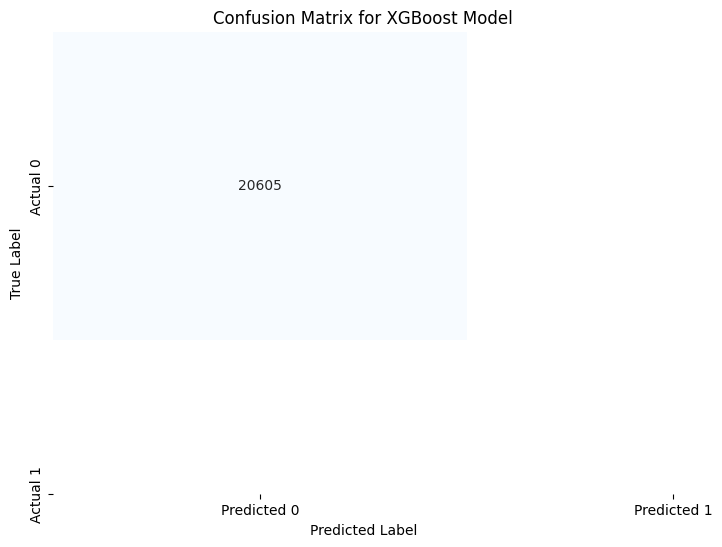

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for XGBoost Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

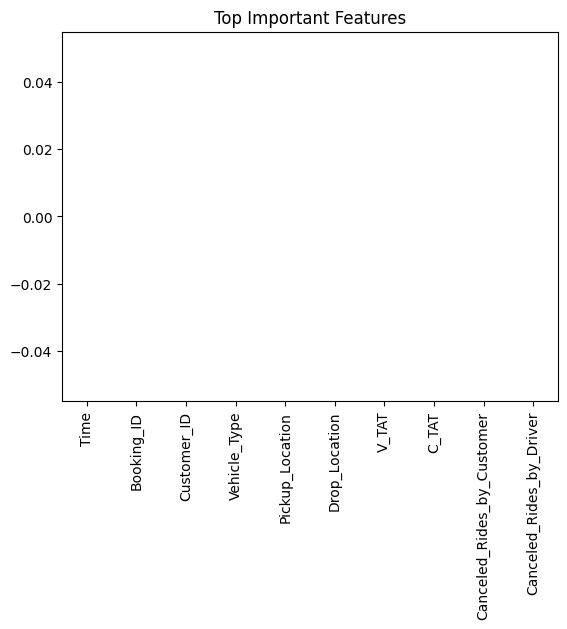

In [14]:
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

feat_imp = pd.Series(importance, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')
plt.title("Top Important Features")
plt.show()

### Exploratory Data Analysis (EDA) and Visualizations

correlation heatmap

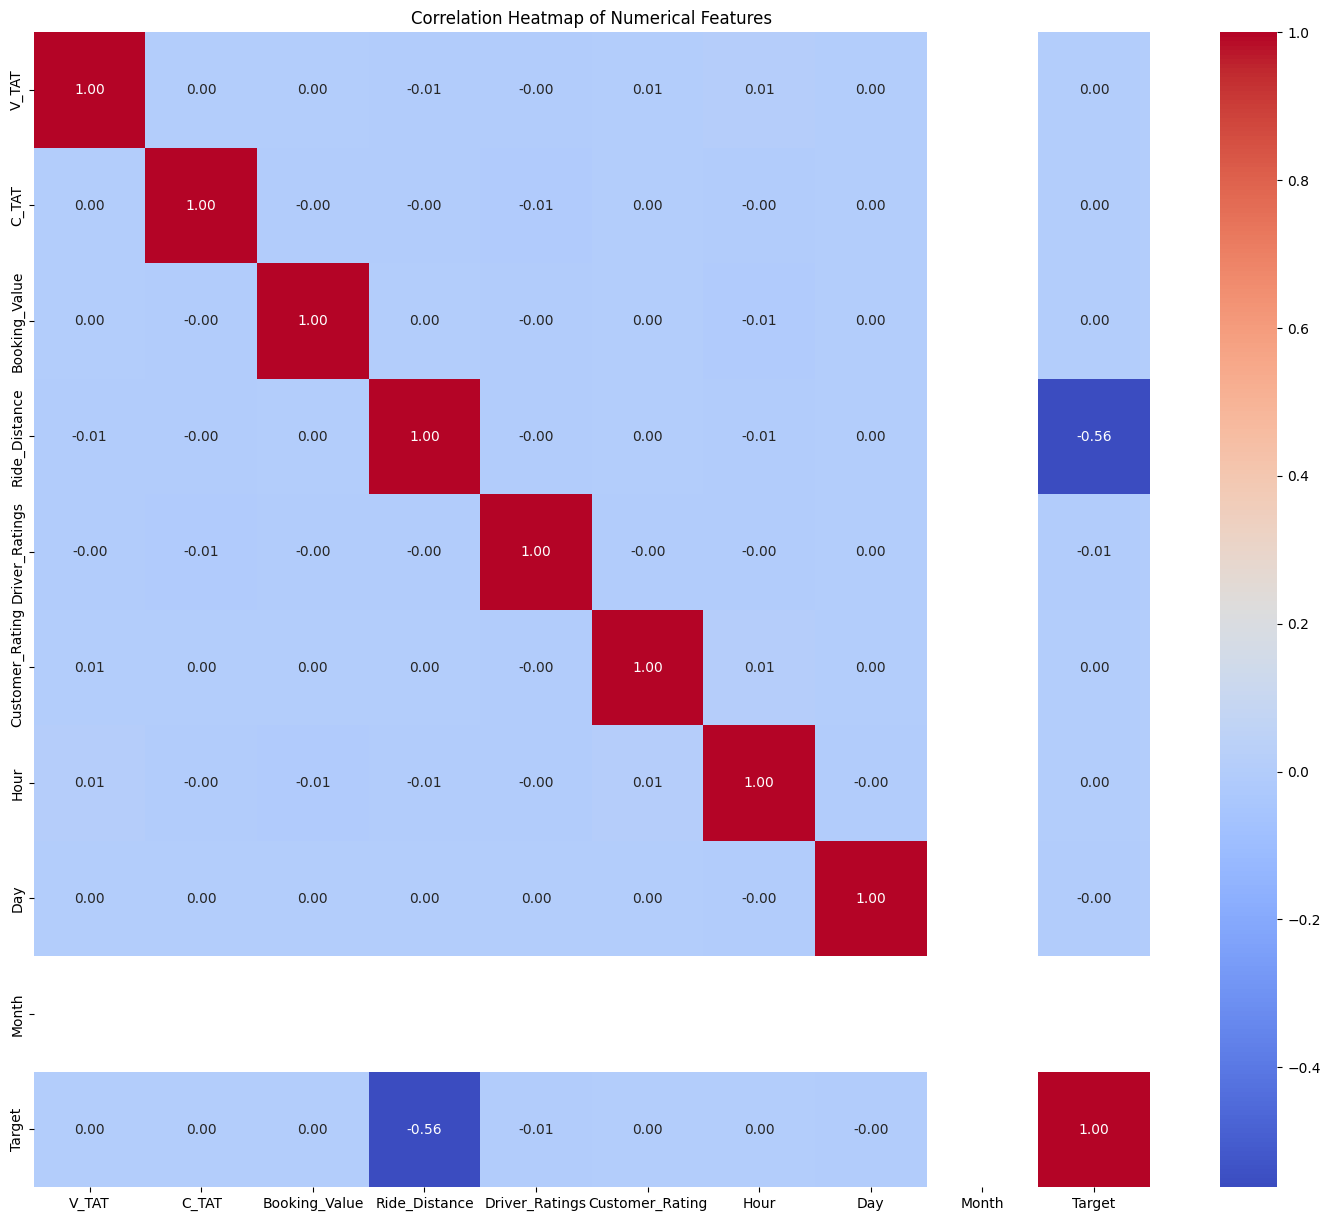

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 15))
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Let's also look at the distributions of some key numerical features like `Booking_Value` and `Ride_Distance`.

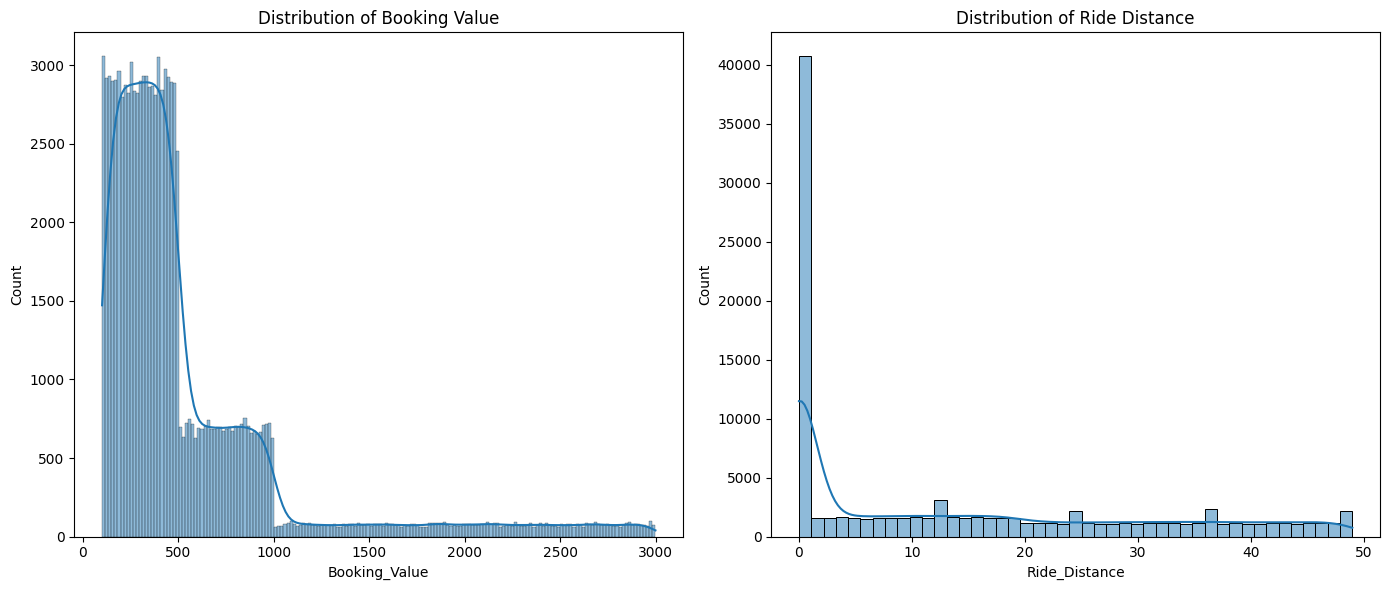

In [25]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Booking_Value'], kde=True)
plt.title('Distribution of Booking Value')

plt.subplot(1, 2, 2)
sns.histplot(df['Ride_Distance'], kde=True)
plt.title('Distribution of Ride Distance')

plt.tight_layout()
plt.show()

 cancellation rate by `Vehicle_Type`.

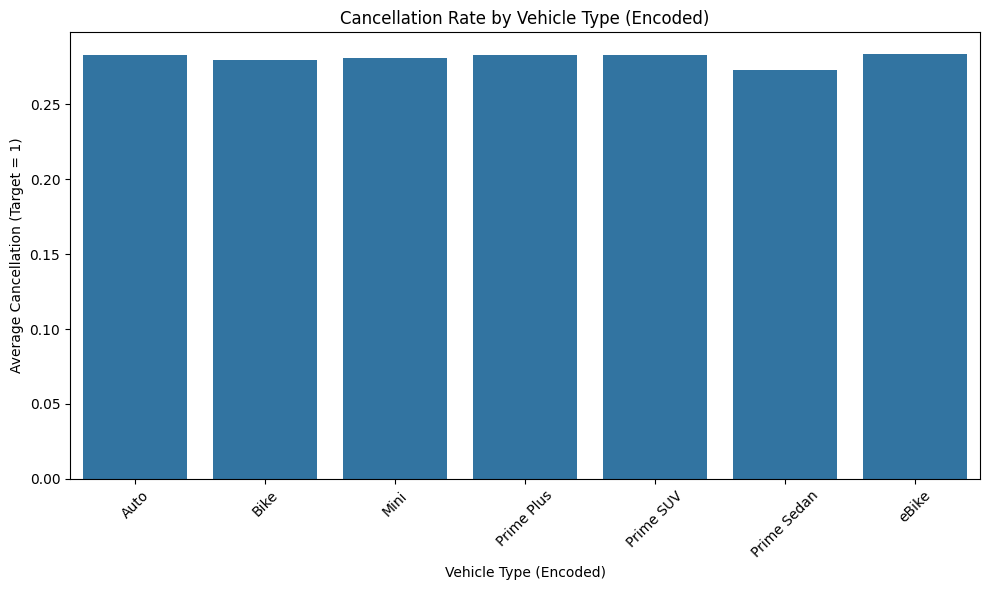

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Vehicle_Type', y='Target', data=df.groupby('Vehicle_Type')['Target'].mean().reset_index())
plt.title('Cancellation Rate by Vehicle Type (Encoded)')
plt.xlabel('Vehicle Type (Encoded)')
plt.ylabel('Average Cancellation (Target = 1)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Time-Based Analysis and Visualizations


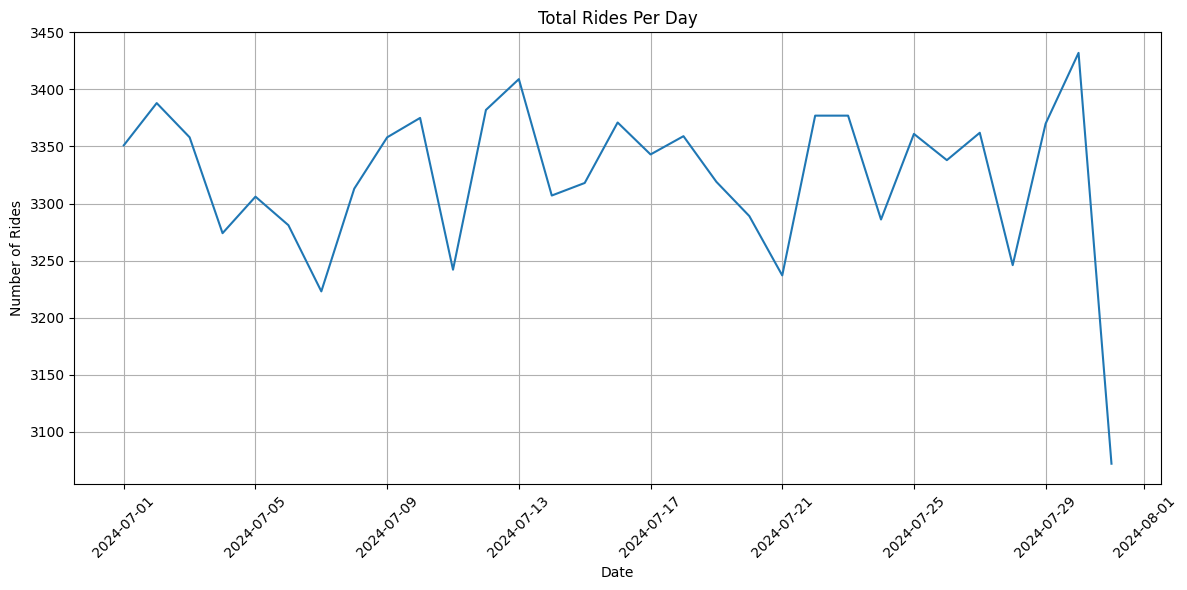

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 1. Rides per day
daily_rides = df.groupby(df['Date'].dt.date).size().reset_index(name='Ride_Count')
daily_rides['Date'] = pd.to_datetime(daily_rides['Date']) # Convert back to datetime for plotting

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Ride_Count', data=daily_rides)
plt.title('Total Rides Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Rides')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_14695/757698574.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Hour', y='Ride_Count', data=peak_hours, palette='viridis')


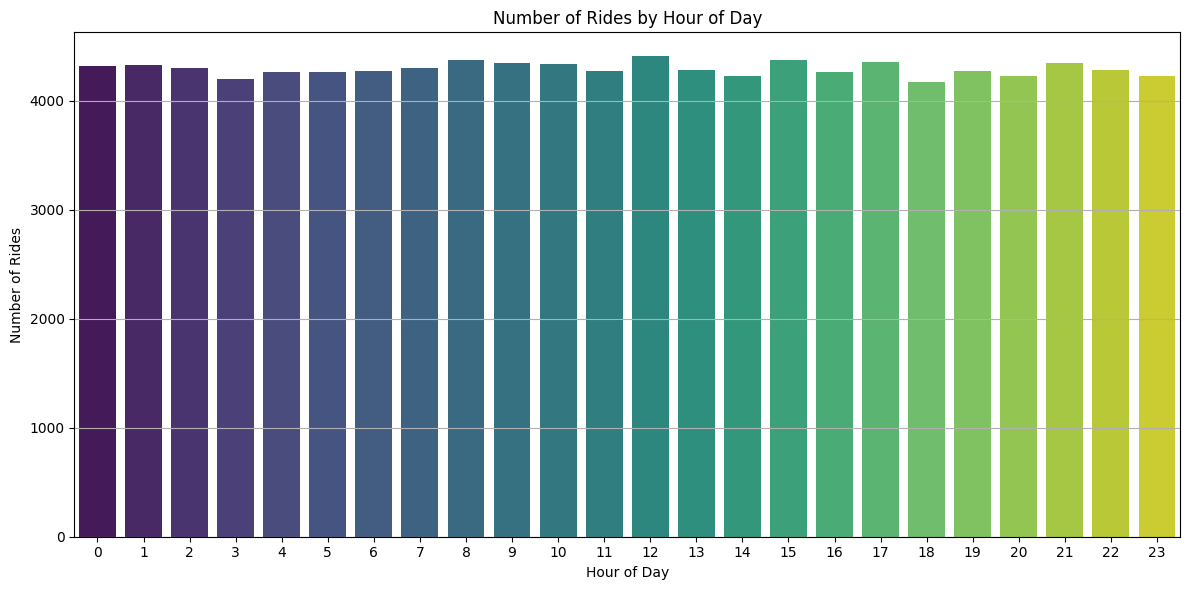

In [32]:
# 2. Peak hours analysis
peak_hours = df.groupby('Hour').size().reset_index(name='Ride_Count')

plt.figure(figsize=(12, 6))
sns.barplot(x='Hour', y='Ride_Count', data=peak_hours, palette='viridis')
plt.title('Number of Rides by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14695/1500929137.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Time_of_Day', y='Ride_Count', data=time_of_day_demand, palette='magma')


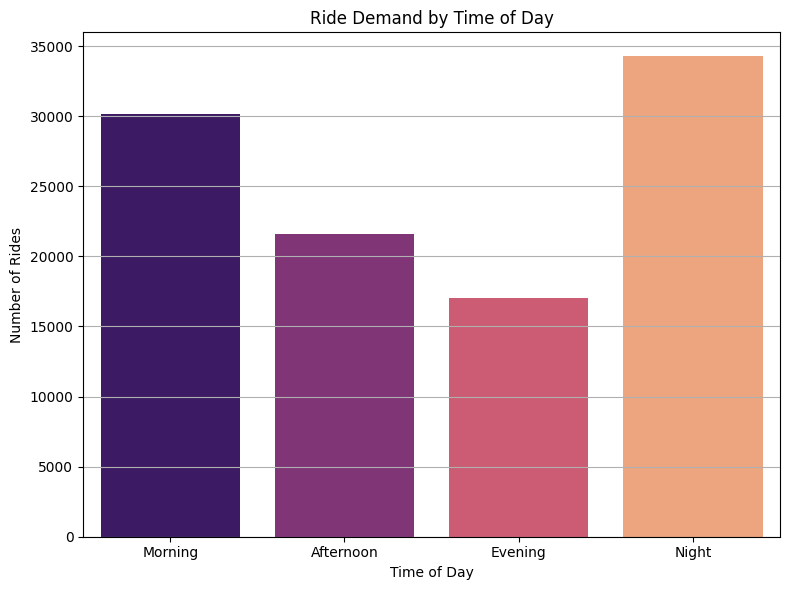

In [33]:
# 3. Ride demand by time of day (Morning, Afternoon, Evening, Night)
def get_time_of_day(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else: return 'Night'

df['Time_of_Day'] = df['Hour'].apply(get_time_of_day)

time_of_day_demand = df.groupby('Time_of_Day').size().reindex([
    'Morning', 'Afternoon', 'Evening', 'Night'
]).reset_index(name='Ride_Count')

plt.figure(figsize=(8, 6))
sns.barplot(x='Time_of_Day', y='Ride_Count', data=time_of_day_demand, palette='magma')
plt.title('Ride Demand by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Rides')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14695/3243018257.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_Week', y='Ride_Count', data=weekday_weekend_demand, palette='cividis')


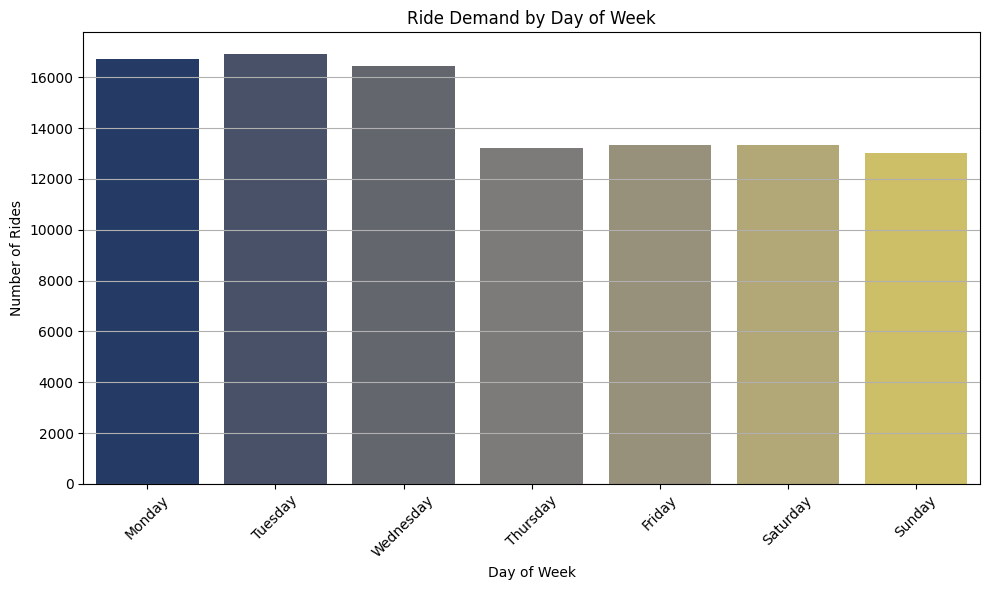

In [34]:
# 4. Weekday vs Weekend demand
df['Day_of_Week'] = df['Date'].dt.day_name()

# Order days for plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_weekend_demand = df.groupby('Day_of_Week').size().reindex(day_order).reset_index(name='Ride_Count')

plt.figure(figsize=(10, 6))
sns.barplot(x='Day_of_Week', y='Ride_Count', data=weekday_weekend_demand, palette='cividis')
plt.title('Ride Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

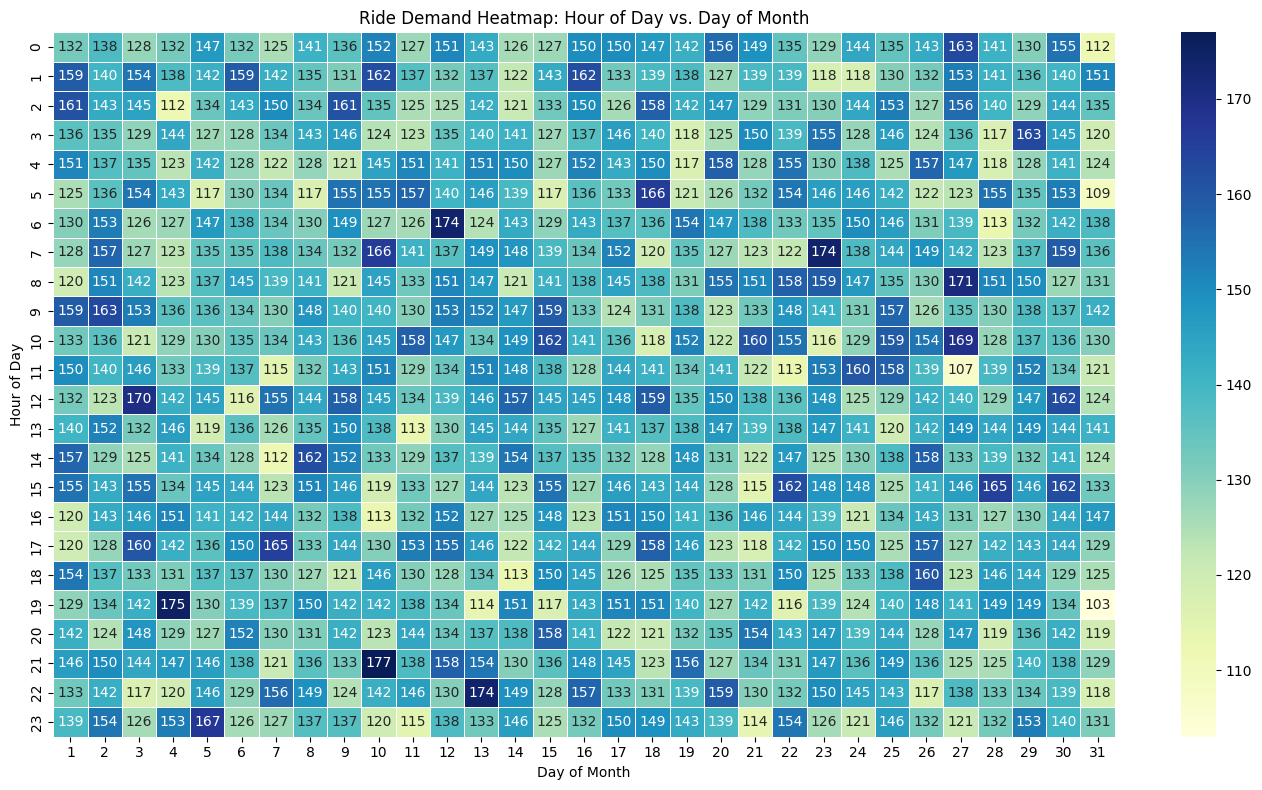

In [35]:
# 5. Heatmap: Hour vs Day demand
# Create 'day_of_month' from the 'Date' column
df['Day_of_Month'] = df['Date'].dt.day

hour_day_heatmap_data = df.groupby(['Hour', 'Day_of_Month']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(hour_day_heatmap_data, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)
plt.title('Ride Demand Heatmap: Hour of Day vs. Day of Month')
plt.xlabel('Day of Month')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()

### Revenue & Fare Analysis 💰

In [38]:
# 1. Total Revenue
total_revenue = df['Booking_Value'].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $56,534,614.00


In [39]:
# 2. Average Ride Fare
average_fare = df['Booking_Value'].mean()
print(f"Average Ride Fare: ${average_fare:,.2f}")

Average Ride Fare: $548.75


In [40]:
# 3. Revenue by Pickup Location (Top 10)
revenue_by_pickup = df.groupby('Pickup_Location')['Booking_Value'].sum().sort_values(ascending=False)
print("\nRevenue by Pickup Location (Top 10):")
display(revenue_by_pickup.head(10))


Revenue by Pickup Location (Top 10):


,Booking_Value
Pickup_Location,
RT Nagar,1225150
Banashankari,1220409
Nagarbhavi,1211057
Yeshwanthpur,1188522
Frazer Town,1175684
Hosur Road,1168154
Tumkur Road,1166372
Basavanagudi,1165243
Cox Town,1163196


In [41]:
# 4. Revenue by Drop Location (Top 10)
revenue_by_drop = df.groupby('Drop_Location')['Booking_Value'].sum().sort_values(ascending=False)
print("\nRevenue by Drop Location (Top 10):")
display(revenue_by_drop.head(10))


Revenue by Drop Location (Top 10):


,Booking_Value
Drop_Location,
Peenya,1219900
Mysore Road,1204904
Vijayanagar,1184720
Shantinagar,1179200
Magadi Road,1174883
Sahakar Nagar,1161493
Koramangala,1153159
MG Road,1148577
Marathahalli,1148542


In [42]:
# 5. Revenue by Vehicle Type
revenue_by_vehicle = df.groupby('Vehicle_Type')['Booking_Value'].sum().sort_values(ascending=False)
print("\nRevenue by Vehicle Type:")
display(revenue_by_vehicle)


Revenue by Vehicle Type:


,Booking_Value
Vehicle_Type,
Prime Sedan,8298612
eBike,8181523
Auto,8092210
Prime Plus,8050889
Mini,7990996
Bike,7987054
Prime SUV,7933330


In [43]:
# 6. Peak Revenue Hours
peak_revenue_hours = df.groupby('Hour')['Booking_Value'].sum().sort_values(ascending=False)
print("\nPeak Revenue Hours (Top 5):")
display(peak_revenue_hours.head(5))


Peak Revenue Hours (Top 5):


,Booking_Value
Hour,
13,2444769
7,2444489
12,2436926
1,2416576
0,2399829


In [44]:
# 7. High-Value Customers (Top 10 by total spending)
high_value_customers = df.groupby('Customer_ID')['Booking_Value'].sum().sort_values(ascending=False)
print("\nHigh-Value Customers (Top 10):")
display(high_value_customers.head(10))


High-Value Customers (Top 10):


,Booking_Value
Customer_ID,
CID785112,8025
CID308763,6281
CID734557,6177
CID353074,6110
CID836942,6019
CID868113,5986
CID389515,5970
CID695232,5962
CID497169,5949


### Customer Behavior Analysis 👤

In [45]:
# 1. Total Unique Customers
unique_customers = df['Customer_ID'].nunique()
print(f"Total Unique Customers: {unique_customers}")

# 2. Number of Bookings per Customer
bookings_per_customer = df.groupby('Customer_ID').size().sort_values(ascending=False)
print("\nBookings per Customer (Top 10):")
display(bookings_per_customer.head(10))

# 3. Repeat Customers
repeat_customers = bookings_per_customer[bookings_per_customer > 1].count()
print(f"\nNumber of Repeat Customers: {repeat_customers}")
print(f"Percentage of Repeat Customers: {(repeat_customers / unique_customers * 100):.2f}%")

# 4. Average Rides per User
avg_rides_per_user = bookings_per_customer.mean()
print(f"\nAverage Rides per User: {avg_rides_per_user:.2f}")

Total Unique Customers: 94544

Bookings per Customer (Top 10):


,0
Customer_ID,
CID954071,5
CID836942,4
CID952434,4
CID309168,4
CID635963,4
CID969725,4
CID199017,4
CID966929,4
CID288207,4



Number of Repeat Customers: 7954
Percentage of Repeat Customers: 8.41%

Average Rides per User: 1.09


In [46]:
# 5. Customer Lifetime Value (CLV) - simplified by total spending
clv = df.groupby('Customer_ID')['Booking_Value'].sum().sort_values(ascending=False)
print("\nCustomer Lifetime Value (CLV) - Top 10 by total spending:")
display(clv.head(10))


Customer Lifetime Value (CLV) - Top 10 by total spending:


,Booking_Value
Customer_ID,
CID785112,8025
CID308763,6281
CID734557,6177
CID353074,6110
CID836942,6019
CID868113,5986
CID389515,5970
CID695232,5962
CID497169,5949



Customer Segmentation by Booking Frequency:


,Segment,Count
0,Frequent User,94544


/tmp/ipykernel_14695/370312972.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Count', data=customer_segments, palette='pastel')


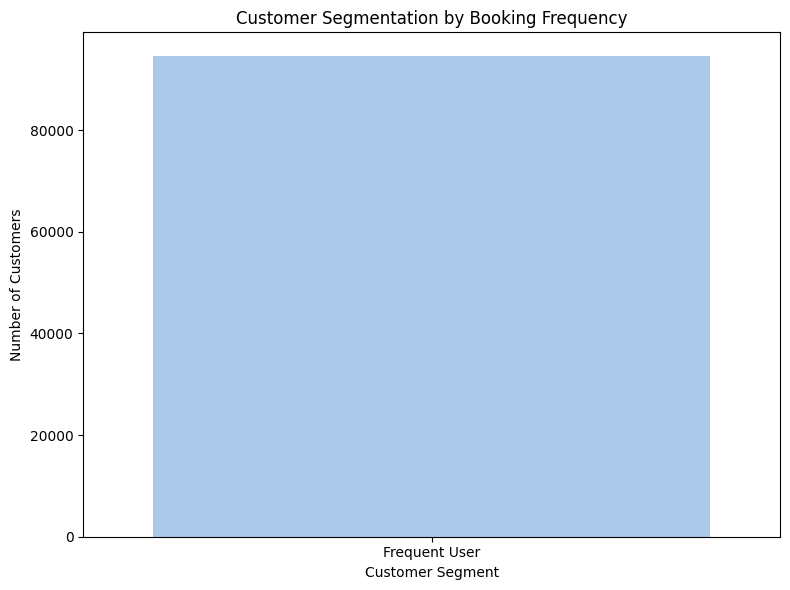

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Segment customers based on booking frequency
# Define thresholds for segmentation (these can be adjusted)
frequent_threshold = bookings_per_customer.quantile(0.75) # Top 25% of customers by bookings
occasional_threshold = bookings_per_customer.quantile(0.25) # Bottom 25% of customers by bookings

def segment_customer(num_bookings):
    if num_bookings >= frequent_threshold:
        return 'Frequent User'
    elif num_bookings <= occasional_threshold:
        return 'Occasional User'
    else:
        return 'Regular User'

# Apply segmentation
customer_segments = bookings_per_customer.apply(segment_customer).value_counts().reset_index()
customer_segments.columns = ['Segment', 'Count']

print("\nCustomer Segmentation by Booking Frequency:")
display(customer_segments)

# Visualize customer segmentation
plt.figure(figsize=(8, 6))
sns.barplot(x='Segment', y='Count', data=customer_segments, palette='pastel')
plt.title('Customer Segmentation by Booking Frequency')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [36]:
print("Booking_Status value counts:")
print(df['Booking_Status'].value_counts())
print("\nTarget value counts:")
print(df['Target'].value_counts())

Booking_Status value counts:
Booking_Status
Success                 63967
Canceled by Driver      18434
Canceled by Customer    10499
Driver Not Found        10124
Name: count, dtype: int64

Target value counts:
Target
0    74091
1    28933
Name: count, dtype: int64


### Driver Performance Analysis 🚖

In [48]:
# 1. Driver Cancellation Rate
canceled_by_driver_count = df[df['Booking_Status'] == 'Canceled by Driver'].shape[0]
successfully_completed_rides = df[df['Booking_Status'] == 'Success'].shape[0]

# Assuming a driver was assigned for 'Success' and 'Canceled by Driver' bookings
total_rides_with_driver_involvement = canceled_by_driver_count + successfully_completed_rides

driver_cancellation_rate = (canceled_by_driver_count / total_rides_with_driver_involvement) * 100
print(f"Driver Cancellation Rate: {driver_cancellation_rate:.2f}%")

# 2. Average Driver Rating
average_driver_rating = df['Driver_Ratings'].mean()
print(f"Average Driver Rating: {average_driver_rating:.2f}")


Driver Cancellation Rate: 22.37%
Average Driver Rating: 4.00


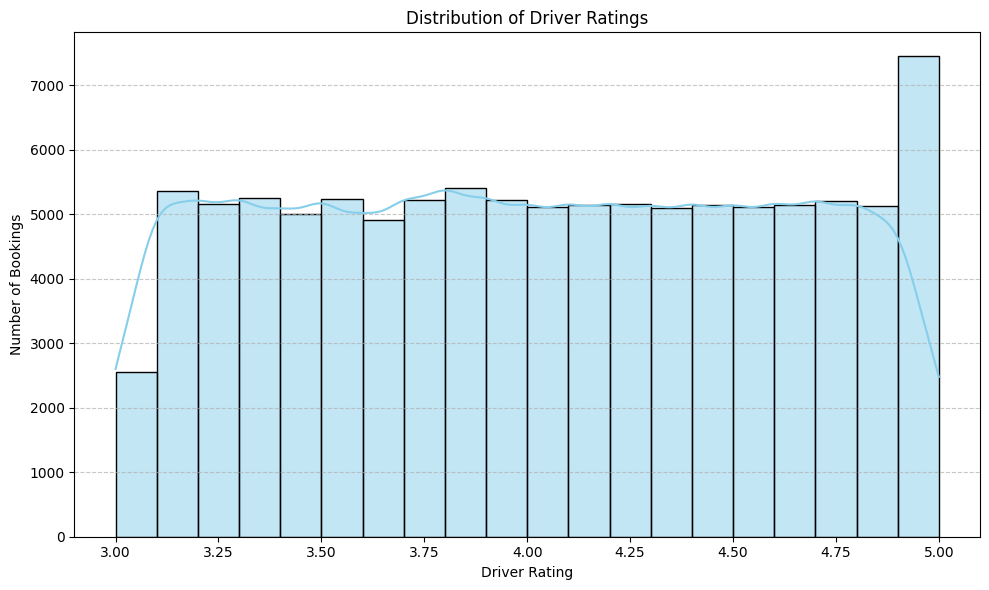

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Distribution of Driver Ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['Driver_Ratings'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Distribution of Driver Ratings')
plt.xlabel('Driver Rating')
plt.ylabel('Number of Bookings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Location-Based Analysis 📍

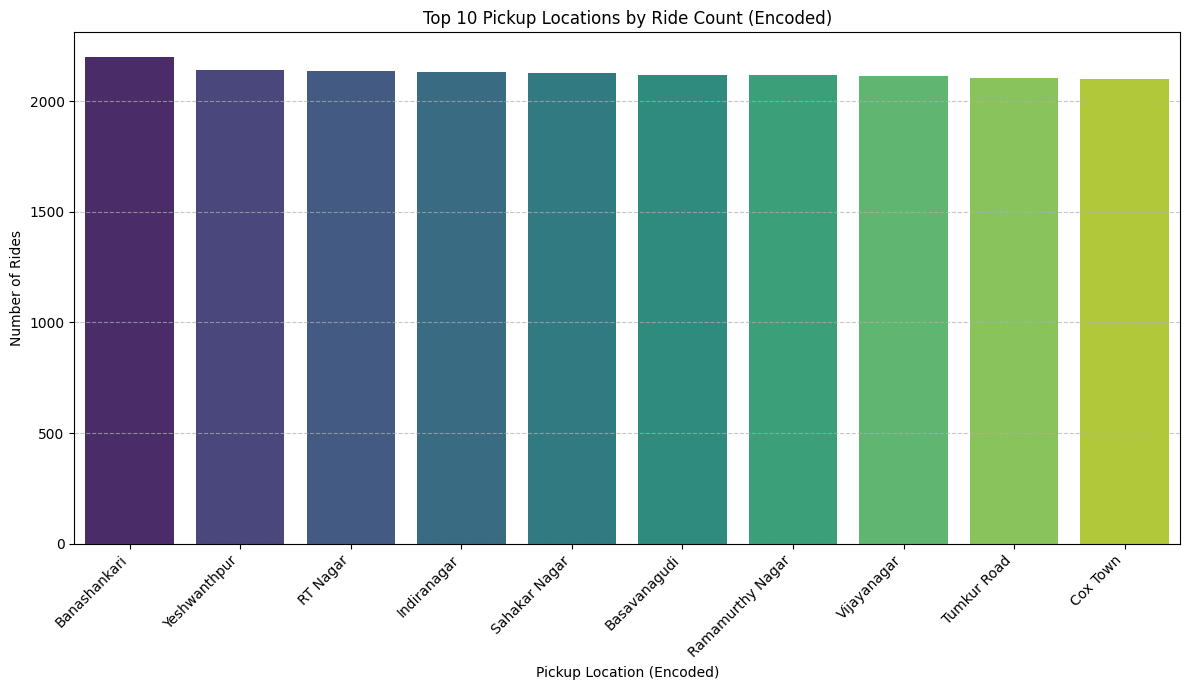

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top Pickup Locations by Ride Count
pickup_demand = df['Pickup_Location'].value_counts().head(10).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=pickup_demand.index, y=pickup_demand.values, palette='viridis', hue=pickup_demand.index, legend=False)
plt.title('Top 10 Pickup Locations by Ride Count (Encoded)')
plt.xlabel('Pickup Location (Encoded)')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

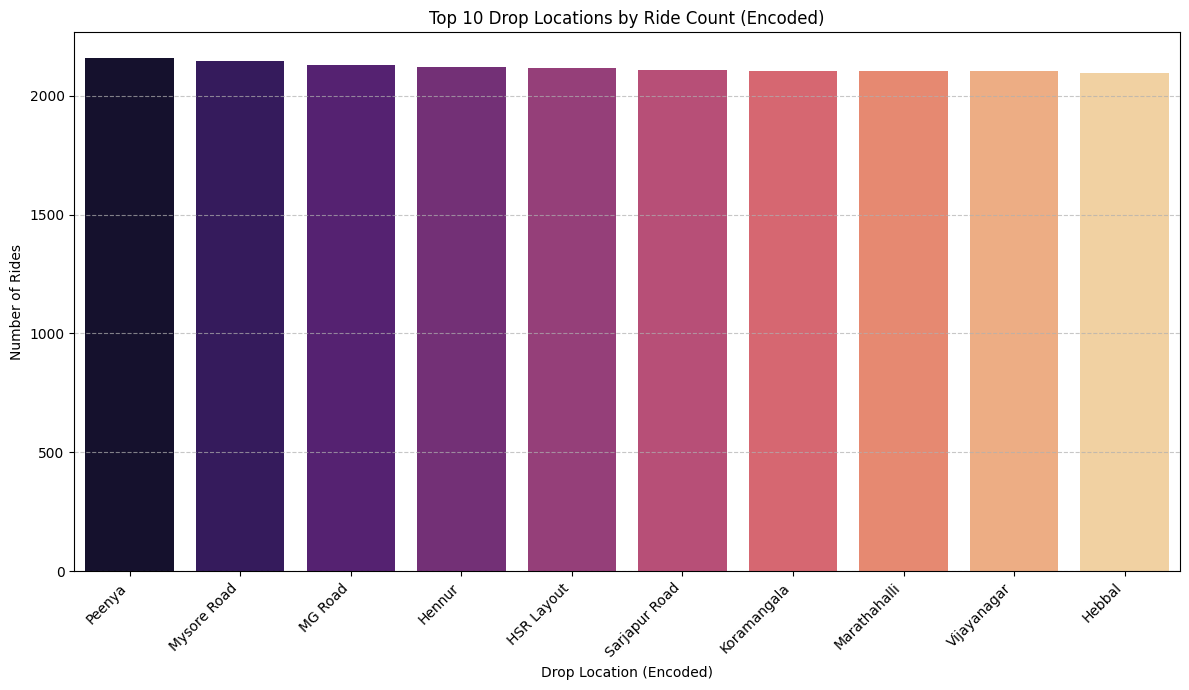

In [53]:
# 2. Top Drop Locations by Ride Count
drop_demand = df['Drop_Location'].value_counts().head(10).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=drop_demand.index, y=drop_demand.values, palette='magma', hue=drop_demand.index, legend=False)
plt.title('Top 10 Drop Locations by Ride Count (Encoded)')
plt.xlabel('Drop Location (Encoded)')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ride Distance & Duration Analysis

In [54]:
# 1. Average Trip Distance
average_trip_distance = df['Ride_Distance'].mean()
print(f"Average Trip Distance: {average_trip_distance:.2f} units")


Average Trip Distance: 14.19 units


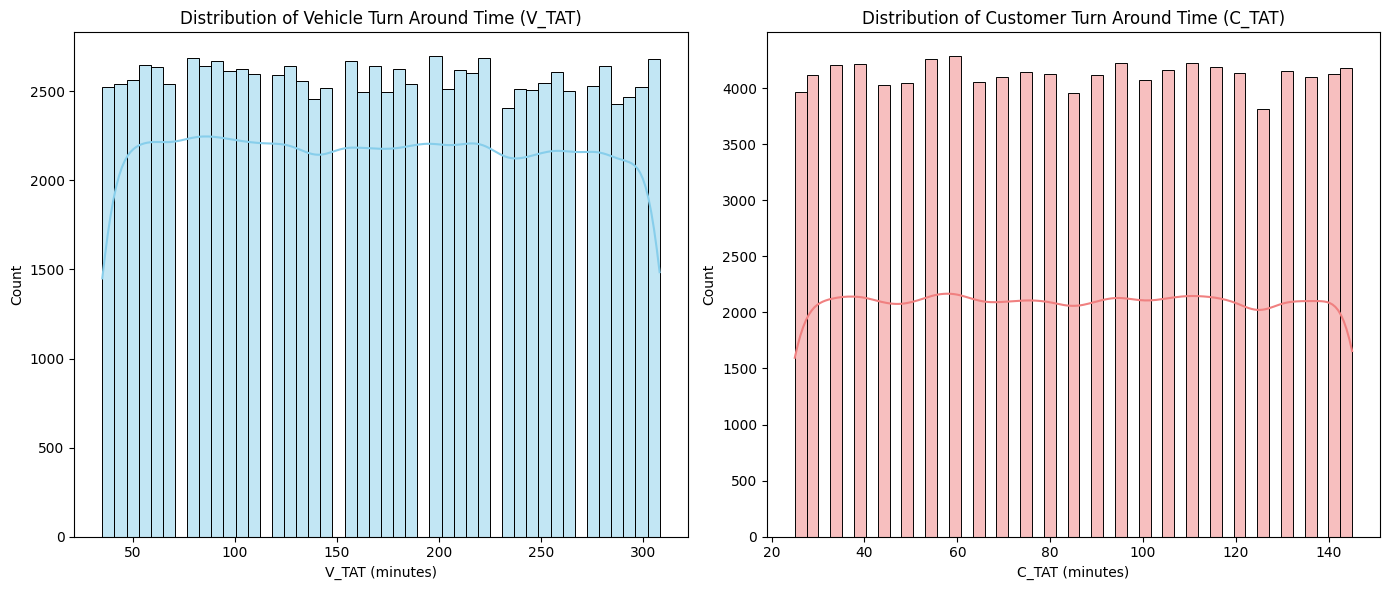

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Trip Duration Distribution (using V_TAT and C_TAT as proxies)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['V_TAT'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of Vehicle Turn Around Time (V_TAT)')
plt.xlabel('V_TAT (minutes)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['C_TAT'].dropna(), kde=True, color='lightcoral')
plt.title('Distribution of Customer Turn Around Time (C_TAT)')
plt.xlabel('C_TAT (minutes)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


Correlation between Ride Distance and Booking Value: 0.00


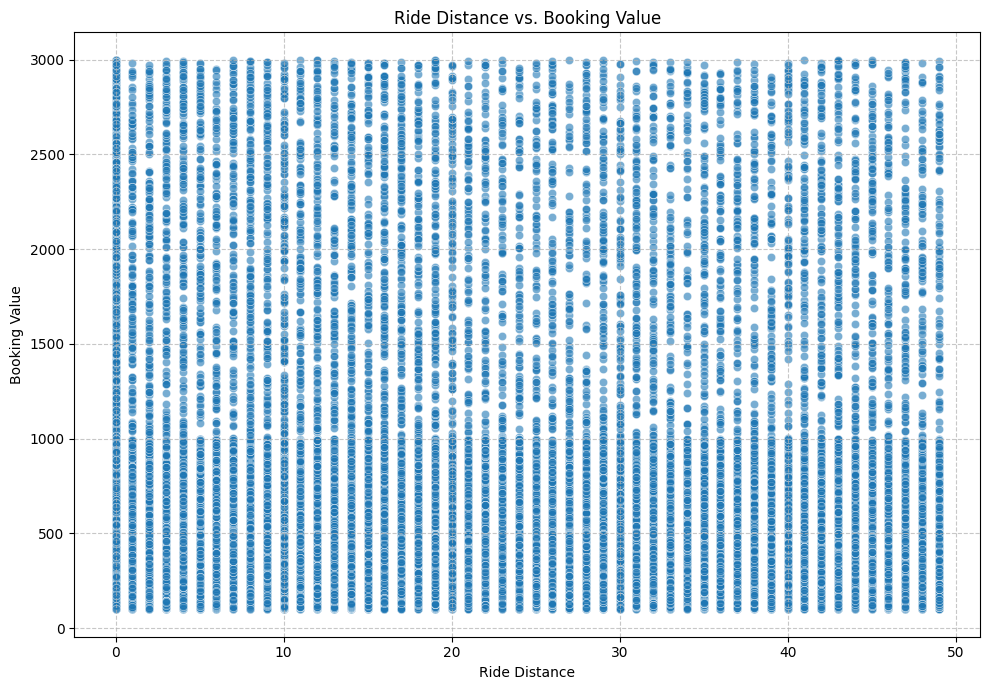

In [56]:
# 3. Distance vs Fare Correlation
correlation = df['Ride_Distance'].corr(df['Booking_Value'])
print(f"Correlation between Ride Distance and Booking Value: {correlation:.2f}")

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Ride_Distance', y='Booking_Value', data=df, alpha=0.6)
plt.title('Ride Distance vs. Booking Value')
plt.xlabel('Ride Distance')
plt.ylabel('Booking Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Payment Analysis 💳

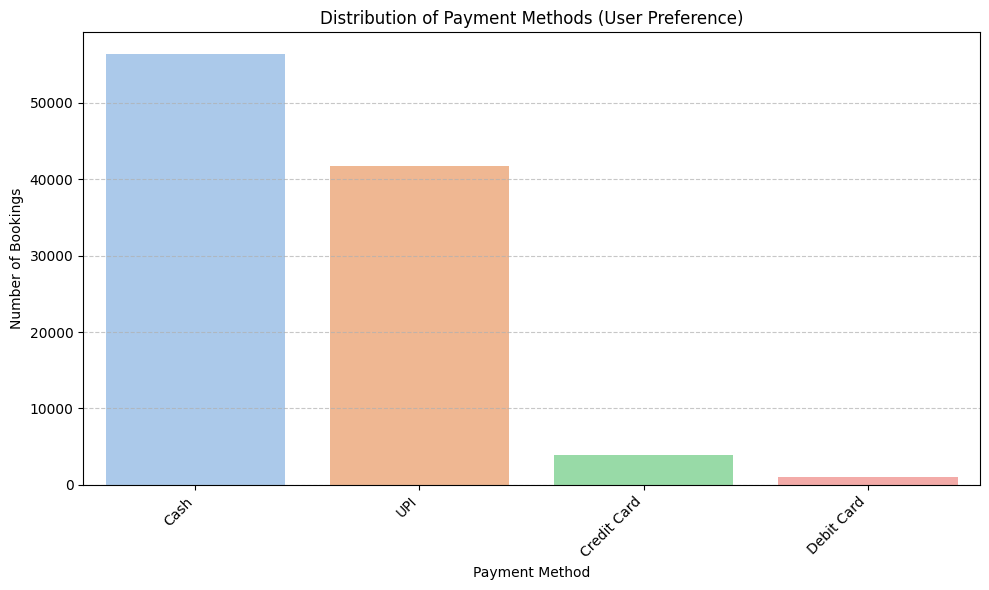

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Payment Methods Distribution (User Preference Trends)
payment_method_counts = df['Payment_Method'].value_counts().reset_index()
payment_method_counts.columns = ['Payment_Method', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Payment_Method', y='Count', data=payment_method_counts, palette='pastel', hue='Payment_Method', legend=False)
plt.title('Distribution of Payment Methods (User Preference)')
plt.xlabel('Payment Method')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Revenue by Payment Type:


,Payment_Method,Booking_Value
0,Cash,31018062
1,UPI,22812934
2,Credit Card,2155845
3,Debit Card,547329


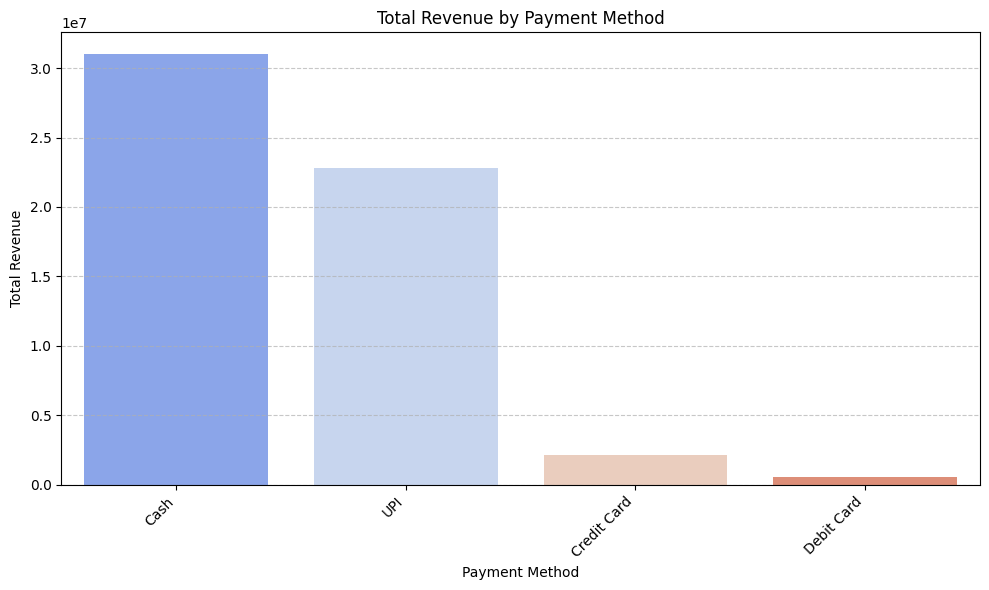

In [58]:
# 2. Revenue by Payment Type
revenue_by_payment_type = df.groupby('Payment_Method')['Booking_Value'].sum().sort_values(ascending=False).reset_index()

print("\nRevenue by Payment Type:")
display(revenue_by_payment_type)

plt.figure(figsize=(10, 6))
sns.barplot(x='Payment_Method', y='Booking_Value', data=revenue_by_payment_type, palette='coolwarm', hue='Payment_Method', legend=False)
plt.title('Total Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Ride Type Analysis 🚲🚗


Distribution of Ride Types:


,Vehicle_Type,Count
0,Prime Sedan,14877
1,eBike,14816
2,Auto,14755
3,Prime Plus,14707
4,Bike,14662
5,Prime SUV,14655
6,Mini,14552


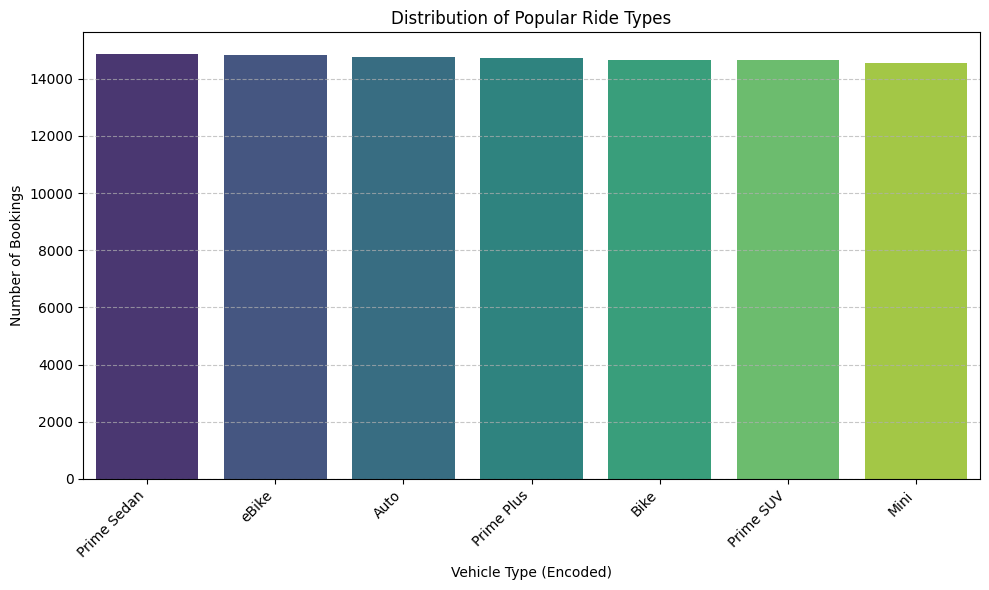

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mini / Prime / Auto / Bike distribution (Popular Ride Types)
ride_type_counts = df['Vehicle_Type'].value_counts().reset_index()
ride_type_counts.columns = ['Vehicle_Type', 'Count']

print("\nDistribution of Ride Types:")
display(ride_type_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x='Vehicle_Type', y='Count', data=ride_type_counts, palette='viridis', hue='Vehicle_Type', legend=False)
plt.title('Distribution of Popular Ride Types')
plt.xlabel('Vehicle Type (Encoded)')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Revenue by Ride Category:


,Vehicle_Type,Booking_Value
0,Prime Sedan,8298612
1,eBike,8181523
2,Auto,8092210
3,Prime Plus,8050889
4,Mini,7990996
5,Bike,7987054
6,Prime SUV,7933330


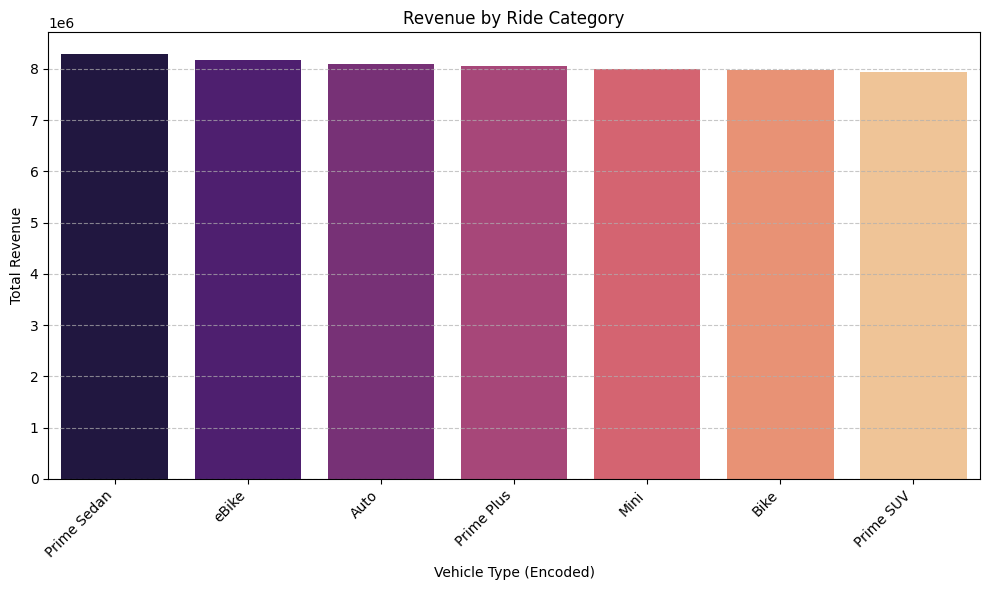

In [60]:
# 2. Revenue by Ride Category
revenue_by_ride_type = df.groupby('Vehicle_Type')['Booking_Value'].sum().sort_values(ascending=False).reset_index()

print("\nRevenue by Ride Category:")
display(revenue_by_ride_type)

plt.figure(figsize=(10, 6))
sns.barplot(x='Vehicle_Type', y='Booking_Value', data=revenue_by_ride_type, palette='magma', hue='Vehicle_Type', legend=False)
plt.title('Revenue by Ride Category')
plt.xlabel('Vehicle Type (Encoded)')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**THANK YOU !**